In [67]:
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas_datareader import data
from sklearn.metrics import mean_squared_error
from pmdarima import auto_arima
from statsmodels.tsa.arima_model import ARIMA
from prophet import Prophet
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM

import warnings
warnings.filterwarnings("ignore")

In [133]:
def predict_price(ticker, ml_model):
    
    start_date = '2019-01-01'

    today = datetime.date.today()
    yesterday = today - datetime.timedelta(days=1)
    end_date = yesterday

    panel_data = data.DataReader([ticker], 'yahoo', start_date, end_date)
    
    # ml model: auto arima, arima, prohphet, linear regression, LSTM
    if ml_model == 'auto arima':
        return ml_auto_arima(ticker, panel_data)
    elif ml_model == 'arima':
        return ml_arima(ticker, panel_data)
    elif ml_model == 'prophet':
        return ml_prophet(ticker, panel_data)
    elif ml_model == 'LSTM':
        return ml_LSTM(ticker, panel_data)

In [134]:
#test
predict_price('GOOGL', 'auto arima')

{'today_price': 2544.7403936860146,
 'yesterday_price': 2977.0400390625,
 'real_vs_prediction':              Prediction        GOOGL
 Date                                
 2021-04-15  2246.362544  2285.250000
 2021-04-16  2248.049376  2282.750000
 2021-04-19  2250.186913  2289.760010
 2021-04-20  2252.251004  2279.010010
 2021-04-21  2254.327064  2278.350098
 ...                 ...          ...
 2021-11-01  2534.368481  2869.939941
 2021-11-02  2536.442863  2908.649902
 2021-11-03  2538.517246  2931.959961
 2021-11-04  2540.591628  2965.350098
 2021-11-05  2542.666011  2977.040039
 
 [144 rows x 2 columns],
 'rmse': 63917.77938390901}

tickers = ['AAPL']

start_date = '2019-01-01'

today = datetime.date.today()
yesterday = today - datetime.timedelta(days=1)
end_date = yesterday

'''User pandas_reader.data.DataReader to load data'''
panel_data = data.DataReader(tickers, 'yahoo', start_date, end_date)


'''df = panel_data['Close']'''
df = panel_data
df.head()

# Auto ARIMA

In [130]:
from pmdarima import auto_arima

def ml_auto_arima(ticker, df):
    close = df['Close']
    
    #split data (train:test = 0.8:0.2)
    train_ratio = 0.8
    train_size = int(df.shape[0] * train_ratio)
    test_size = df.shape[0] - train_size

    train = close.head(train_size)
    test = close.tail(test_size)
    
    # training the model
    model = auto_arima(train, start_p=1, start_q=1,max_p=6, max_q=3, m=12, seasonal=True, error_action='ignore',suppress_warnings=True)
    model.fit(train)
    
    # prediction
    forecast = model.predict(n_periods=test_size+1)
    today_prediction = forecast[-1]
    forecast = pd.DataFrame(forecast[:-1],index = test.index,columns=['Prediction'])
    
    # combine test and forecast dataframes
    result = pd.concat([forecast, test], axis = 1)
    # result.plot()

    # calculating rmse 
    MSE_error = mean_squared_error(test, forecast)
    
    # output 
    return {'today_price': today_prediction, 'yesterday_price': test[ticker][-1], 'real_vs_prediction': result, 'rmse': MSE_error}

In [132]:
#test
ml_auto_arima('GOOGL', panel_data)

KeyError: 'GOOGL'

In [ ]:
# 5 days future price prediction
from pmdarima import auto_arima

close = df['Close']
# splitting the data
train_ratio = 0.8
train_size = int(df.shape[0] * train_ratio)
test_size = df.shape[0] - train_size

train = close.head(train_size)
test = close.tail(test_size)

# train.plot()
# test.plot()

model = auto_arima(train, start_p=1, start_q=1,max_p=6, max_q=3, m=12, seasonal=True, error_action='ignore',suppress_warnings=True)
model.fit(train)

forecast = model.predict(n_periods=test_size+5)
today_prediction = forecast[-5:]
forecast = pd.DataFrame(forecast[:-5],index = test.index,columns=['Prediction'])
# forecast = pd.DataFrame(forecast,columns=['Prediction'])

result = pd.concat([forecast, test], axis = 1)
result.plot()

# calculating rmse
MSE_error = mean_squared_error(test, forecast)
print('Testing Mean Squared Error is {}'.format(MSE_error))

# ARIMA

In [112]:
def ml_arima(ticker, df):
    
    # preprocessing data
    train_data, test_data = df[0:int(len(df)*0.8)], df[int(len(df)*0.8):]
    training_data = train_data['Close'].values
    test_data = test_data['Close'].values
    history = [x for x in training_data]
    model_predictions = []
    N_test_observations = len(test_data)
    
    # train model
    for time_point in range(N_test_observations+1):
        try:
            model = ARIMA(history, order=(4,1,0))
            model_fit = model.fit(disp=0)
            output = model_fit.forecast()
            yhat = output[0]
            true_test_value = test_data[time_point]
            history.append(true_test_value)
            model_predictions.append(yhat)
        except:
            today_prediction = yhat
    
    model_predictions = pd.DataFrame(model_predictions,columns=['Prediction'])
    test = pd.DataFrame(test_data, columns = [ticker])
    
    # combine test and forecast dataframes
    result = pd.concat([model_predictions, test], axis = 1)

    # calculating rmse
    MSE_error = mean_squared_error(test, model_predictions)
    
    # output
    return {'today_price': today_prediction[0], 'yesterday_price': test_data[-1], 'real_vs_prediction': result, 'rmse': MSE_error}

In [111]:
#test
ml_arima('AAPL', panel_data)

{'today_price': 151.33736003406227,
 'yesterday_price': array([151.27999878]),
 'real_vs_prediction':      Prediction        AAPL
 0    132.598698  134.500000
 1    134.269200  134.160004
 2    134.453372  134.839996
 3    134.920006  133.110001
 4    133.529731  133.500000
 ..          ...         ...
 139  150.409627  148.960007
 140  149.023244  150.020004
 141  150.131497  151.490005
 142  151.577686  150.960007
 143  151.191262  151.279999
 
 [144 rows x 2 columns],
 'rmse': 3.027762168915083}

In [ ]:
# future 5 days prediction
from statsmodels.tsa.arima_model import ARIMA

train_data, test_data = df[0:int(len(df)*0.7)], df[int(len(df)*0.7):]
training_data = train_data['Close'].values
test_data = test_data['Close'].values
history = [x for x in training_data]
model_predictions = []
future = []
N_test_observations = len(test_data)
for time_point in range(N_test_observations+5):
    try:
        model = ARIMA(history, order=(4,1,0))
        model_fit = model.fit(disp=0)
        output = model_fit.forecast()
        yhat = output[0]
        true_test_value = test_data[time_point]
        history.append(true_test_value)
        model_predictions.append(yhat)
    except:
        future.append(yhat)
        history.append(yhat)
        model_predictions.append(yhat)
#         today_stock_price = yhat
MSE_error = mean_squared_error(test_data, model_predictions[:-5])
print('Testing Mean Squared Error is {}'.format(MSE_error))

In [ ]:
test_set_range = df[int(len(df)*0.7):].index
plt.plot(test_set_range, model_predictions, color='blue', marker='o', linestyle='dashed',label='Predicted Price')
plt.plot(test_set_range, test_data, color='red', label='Actual Price')
plt.title('AAPL Prices Prediction')
plt.xlabel('Date')
plt.ylabel('Prices')
# plt.xticks(np.arange(881,1259,50), df.Date[881:1259:50])
plt.legend()
plt.show()


#future predictions
print("Today's price prediction: ", yhat[0])

# Prophet

In [85]:
def ml_prophet(ticker, df):
    close = df['Close']

    #preparing data
    close.reset_index(inplace = True)
    close = close[['Date', ticker]]
    close.rename(columns={ticker: 'y', 'Date':'ds'}, inplace = True)

    #splitting the data
    train_ratio = 0.8
    train_size = int(df.shape[0] * train_ratio)
    test_size = df.shape[0] - train_size

    train = close.head(train_size)
    test = close.tail(test_size)

    #fit the model
    model = Prophet(daily_seasonality=True)
    model.fit(train)

    #predictions
    close_prices = model.make_future_dataframe(periods=len(test)+1)
    forecast = model.predict(close_prices)
    today_prediction = forecast['yhat'].to_list()[-1]
    
    # combine test and forecast dataframes
    forecast = pd.DataFrame(forecast,index = test.index,columns=['yhat'])
    result = pd.concat([forecast, test], axis = 1)
    
    #rmse
    forecast_valid = forecast['yhat'][-test_size:]
    MSE_error = mean_squared_error(test['y'], forecast_valid)
    
    # renaming columns in result
    result.rename(columns = {'yhat':'Prediction', 'y': ticker}, inplace = True)
    result.drop(columns = ['ds'], inplace = True)
    
    # output
    return {'today_price': today_prediction, 'yesterday_price': test['y'].to_list()[-1], 'real_vs_prediction': result, 'rmse': MSE_error}

In [ ]:
#test
# ml_prophet('AAPL', panel_data)

In [ ]:
# suppose to predict 5 days (work in progress)
from prophet import Prophet

close = df['Close']

#preparing data
close.reset_index(inplace = True)
close = close[['Date', 'AAPL']]
close.rename(columns={'AAPL': 'y', 'Date':'ds'}, inplace = True)

#splitting the data
train_ratio = 0.8
train_size = int(df.shape[0] * train_ratio)
test_size = df.shape[0] - train_size

train = close.head(train_size)
test = close.tail(test_size)

#fit the model
model = Prophet(daily_seasonality=True)
model.fit(train)

#predictions
close_prices = model.make_future_dataframe(periods=len(test))
forecast = model.predict(close_prices)

#rmse
forecast_valid = forecast['yhat'][-test_size:]
MSE_error = mean_squared_error(test['y'], forecast_valid)
print('Testing Mean Squared Error is {}'.format(MSE_error))

#plot
test['Predictions'] = 0
test['Predictions'] = forecast_valid.values

# plt.plot(train['y'])
plt.plot(test['y'], color = 'blue', label = 'Actual Price')
plt.plot(test['Predictions'], color = 'red', label = 'Predicted Price')
plt.title('AAPL Prices Prediction')
plt.xlabel('Date')
plt.ylabel('Prices')
plt.legend()
plt.show()

# LSTM

In [7]:
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM

In [73]:
def ml_LSTM(ticker, df):
    close = df['Close']

    #preparing data
    close.reset_index(inplace = True)
    close = close[['Date', ticker]]

    #splitting the data
    train_ratio = 0.8
    train_size = int(df.shape[0] * train_ratio)
    test_size = df.shape[0] - train_size

    train = close.head(train_size)
    test = close.tail(-test_size)

    close.drop('Date', axis=1, inplace = True)

    #convert into x and y
    scaler = MinMaxScaler(feature_range=(0,1))
    scaled_data = scaler.fit_transform(close)

    x_train, y_train = [], []
    for i in range(60,len(train)):
        x_train.append(scaled_data[i-60:i,0])
        y_train.append(scaled_data[i,0])
    x_train, y_train = np.array(x_train), np.array(y_train)
    x_train = np.reshape(x_train, (x_train.shape[0],x_train.shape[1],1))

    # create and fit the LSTM network
    model = Sequential()
    model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1],1)))
    model.add(LSTM(units=50))
    model.add(Dense(1))

    model.compile(loss='mean_squared_error', optimizer='adam')
    model.fit(x_train, y_train, epochs=1, batch_size=1, verbose=2)

    #prediction
    inputs = close[len(close) - len(test) - 60:].values
    inputs = inputs.reshape(-1,1)
    inputs  = scaler.transform(inputs)

    X_test = []
    for i in range(60,inputs.shape[0]+1):
        X_test.append(inputs[i-60:i,0])
    X_test = np.array(X_test)

    X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
    closing_price = model.predict(X_test)
    closing_price = scaler.inverse_transform(closing_price)
    today_prediction = closing_price[-1]
    closing_price = closing_price[:-1]

    #rmse
    MSE_error = mean_squared_error(test[ticker], closing_price)
    MSE_error
    
    #combine test and prediction dataframe
    test['Predictions'] = closing_price
    test.drop(columns = ['Date'], inplace = True)
    
    # output
    return {'today_price': today_prediction[0], 'yesterday_price': closing_price[-1][0], 'real_vs_prediction': test, 'rmse': MSE_error}

In [ ]:
# test
print(ml_LSTM('AAPL', panel_data))

In [66]:
close = df['Close']

#preparing data
close.reset_index(inplace = True)
close = close[['Date', 'AAPL']]
# close = close.values

#splitting the data
train_ratio = 0.8
train_size = int(df.shape[0] * train_ratio)
test_size = df.shape[0] - train_size

train = close.head(train_size)
test = close.tail(-test_size)

close.drop('Date', axis=1, inplace = True)

#convert into x and y
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(close)

x_train, y_train = [], []
for i in range(60,len(train)):
    x_train.append(scaled_data[i-60:i,0])
    y_train.append(scaled_data[i,0])
x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0],x_train.shape[1],1))

# create and fit the LSTM network
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1],1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(x_train, y_train, epochs=1, batch_size=1, verbose=2)

#prediction
inputs = close[len(close) - len(test) - 60:].values
inputs = inputs.reshape(-1,1)
inputs  = scaler.transform(inputs)

X_test = []
for i in range(60,inputs.shape[0]+1):
    X_test.append(inputs[i-60:i,0])
X_test = np.array(X_test)

X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
closing_price = model.predict(X_test)
closing_price = scaler.inverse_transform(closing_price)
today_price = closing_price[-1]
closing_price = closing_price[:-1]

#rmse
MSE_error = mean_squared_error(test['AAPL'], closing_price)
MSE_error

#for plotting
test['Predictions'] = closing_price
plt.plot(train['AAPL'])
plt.plot(test[['AAPL','Predictions']])
plt.legend()
plt.plot()

516/516 - 7s - loss: 0.0044


36.416483877473055

No handles with labels found to put in legend.


[]

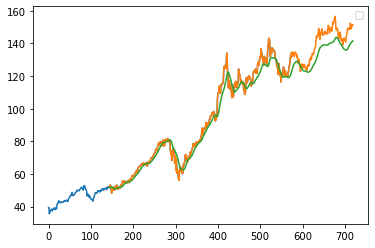

In [36]:
#for plotting
test['Predictions'] = closing_price
plt.plot(train['AAPL'])
plt.plot(test[['AAPL','Predictions']])
plt.legend()
plt.plot()

In [46]:
len(closing_price)

576